## 1. Import Python Libraries

An essential first step is to import the various Python libraries needed for the project.  For example:

```python
# python imports
from crim_intervals import * 
from crim_intervals import importScore 
from crim_intervals import main_objs
from community import community_louvain
```




In [1]:
# python imports
from crim_intervals import * 
from crim_intervals import importScore 
from crim_intervals import main_objs
from community import community_louvain
from copy import deepcopy
from IPython.display import SVG
from collections import Counter
import altair as alt
import glob as glob
import crim_intervals
import crim_intervals.visualizations as viz
from crim_code import *
import numpy as np
import math

import plotly.express as px
import plotly.io as pio


import os
import pandas as pd
import re
import networkx as nx
import requests
from itertools import combinations


import base64
from IPython.display import Image, display
MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    # print("created folder : ", MYDIR)

# else:
#     print(MYDIR, "folder already exists.")
    
MUSDIR = ("MEI")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    # print("created folder : ", MUSDIR)

# else:
#     print(MUSDIR, "folder already exists.")

# code for Quarto and the charting tools
alt.renderers.enable('default')
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import warnings
warnings.filterwarnings('ignore')
    

## 1b.  Import Functions

We also have various functions used in the steps below.  **Do not edit these!** Just run the cell below!

# 2. Import a Score

Here we find a piece to explore.  

Load it from the local `MEI` directory:

```python
# pick a local file
file_name = 'MEI/LC_01.mei'

# load a piece object
piece = importScore(file_name)

```

Or remotely:

```
filename = 'https://crimproject.org/mei/CRIM_Model_0019.mei'

piece = importScore(file_name)
```


In [2]:
filename = 'https://crimproject.org/mei/CRIM_Model_0019.mei'

piece = importScore(filename)
piece.metadata

{'title': 'Veni sponsa Christi',
 'composer': 'Giovanni Pierluigi da Palestrina',
 'date': None}

# 3. Count and Chart the Notes

### 3a. Here we count the notes and report the distributions.

In [3]:
nr = piece.notes()
nr = piece.numberParts(nr).melt()

# count the notes? first we 'melt' the data to make it 'long data'
# melted_notes = notes_rests_num_parts.melt()
melted_notes = nr.rename(columns={'variable': 'voice', 'value': 'pitch'})
melted_notes = melted_notes.dropna()
counted_notes = Counter(melted_notes['pitch'])
counted_notes

Counter({'D5': 26,
         'B4': 46,
         'E5': 11,
         'C5': 38,
         'A4': 61,
         'G4': 74,
         'Rest': 38,
         'G5': 2,
         'F5': 7,
         'F4': 45,
         'G#4': 2,
         'F#4': 5,
         'E4': 62,
         'D4': 66,
         'B3': 39,
         'C4': 58,
         'A3': 38,
         'G3': 33,
         'C#4': 1,
         'E3': 11,
         'F3': 16,
         'F#3': 1,
         'C3': 5,
         'D3': 9})

### 3b.  Bar Chart of Notes, Voices and Ranges

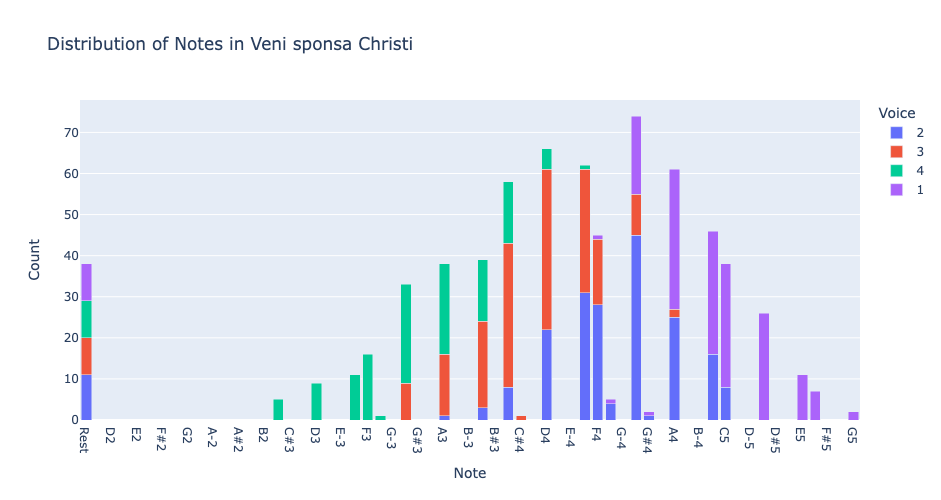

In [4]:
pitch_order = ['Rest','C2', 'D2', 'E-2', 'E2', 'F2', 'F#2', 'G-2', 'G2', 'G#2', 'A-2', 'A2', 'A#2','B-2', 'B2',
    'C3', 'C#3', 'D-3','D3', 'D#3', 'E-3','E3', 'F3', 'F#3', 'G-3',  'G3', 'G#3', 'A-3', 'A3', 'A#3', 'B-3','B3', 'B#3',
    'C4', 'C#4', 'D-4','D4', 'D#4','E-4', 'E4', 'F4', 'F#4', 'G-4',  'G4', 'G#4', 'A-4','A4', 'A#4', 'B-4', 'B4',
    'C5', 'C#5','D-5','D5', 'D#5', 'E-5','E5','F5', 'F#5', 'G-5', 'G5', 'G#5', 'A-5', 'A5', 'A#5', 'B-5', 'B5',
    'C6']

# chart of pitches by voice
grouped_data = melted_notes.groupby(['pitch', 'voice']).size().reset_index(name='count')

# Create the stacked bar chart
chart_title = "Distribution of Notes in " + piece.metadata['title']
fig = px.bar(grouped_data,
             x='pitch',
             y='count',
             color='voice',
             barmode='stack',
             title=chart_title,
             # note that we define pitch_order in the helpers file!
             category_orders={'pitch': pitch_order})

fig.update_layout(xaxis_title="Note", 
                  yaxis_title="Count",
                  legend_title='Voice',
                  height=500,
                  width=750,
                  xaxis={'categoryorder': 'array', 'categoryarray': pitch_order})

fig.show()

## 3c.  Weighted Notes Radar Plot

What about the **pitch class distribution**?  That is:  the 'class' of tone, quite apart from the octave in which it appears? 

And why not also consider the **duration of each note**, which will tell us something more useful about how the piece sounds, in terms of pitch space.

And it might be interesting to see these **weighted note** distributions as a radial (or 'radar' plot), giving us a visual impression of the overall tonal footprint of the piece.







In [5]:
# First we combine the notes and durations into a single table

pitch_class_order = ['C', 'C#', 'D-','D', 'D#', 'E-', 'E', 'E#', 'F', 'F#', 'G-', 'G', 'G#', 'A-','A', 'A#', 'B-', 'B', 'Rest']

melted_notes = piece.notes().melt()
melted_durations = piece.durations().melt()

# combine the melted notes and durs
note_dur = pd.merge(melted_notes, melted_durations, left_index=True, right_index=True)
note_dur = note_dur.dropna()
note_dur.drop(columns=['variable_y'], inplace=True)
note_dur = note_dur.rename(columns={'variable_x': 'voice', 'value_x': 'pitch', 'value_y': 'duration'})

# and now we apply a custom function that reports only the pitch class
# this function was defined above
note_dur['pitch_class'] = note_dur['pitch'].apply(extract_letter)

# finally, group the data by pitch class and find the total duration
note_dur_sums = pd.DataFrame(note_dur.groupby('pitch_class')['duration'].sum()).reset_index(drop=False)

# also find the total duration of notes in the piece, so we can scale the results
total_dur = note_dur_sums['duration'].sum()
note_dur_sums['scaled'] = note_dur_sums['duration'].apply(lambda x: x/total_dur).round(2)
note_dur_sums['pitch_class'] = pd.Categorical(note_dur_sums['pitch_class'], categories=pitch_class_order, ordered=True)
# note_dur_sums



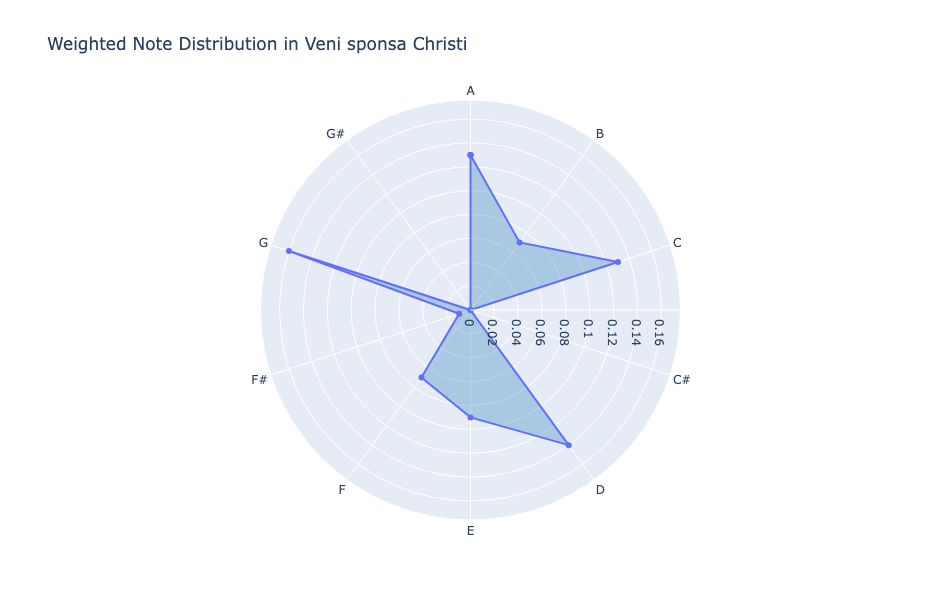

In [6]:
# set title and size
chart_title = 'Weighted Note Distribution in ' + piece.metadata['title']
height = 600
width = 600

# to close the diagram, we add the first row again at the end:
note_dur_sums.iloc[-1] = note_dur_sums.iloc[0]
note_dur_sums

# Single piece plot
fig = px.line_polar(
    note_dur_sums,
    r='scaled',
    theta='pitch_class',
    category_orders={'pitch': pitch_class_order},
    line_close=True,
    range_r=[0, note_dur_sums['scaled'].max() * 1.1],
    markers=True,
    title = chart_title,
    height=height,
    width=width
    
)

fig.update_traces(
    fill='toself',
    fillcolor='rgba(31, 119, 180, 0.3)',
    line=dict(width=2))

fig.show()  

# Save the figure as an interactive HTML file
fig.write_html("weighted_notes.html")

# 4 Ngrams:  Melodic

### 4a. Here are all the mel ngs.

In [7]:

mel = piece.melodic(kind='d', end=False)
mel = piece.numberParts(df=mel)
mel_ng = piece.ngrams(df=mel, n=3)
# clean up the tuples as strings
mel_ng_clean = mel_ng.map(convert_tuple)
mel_ng_clean

,1,2,3,4
0.0,-3_3_2,,,
8.0,3_2_-2,-3_3_2,,
12.0,2_-2_-3,,,
16.0,-2_-3_2,3_2_-2,,
20.0,-3_2_2,2_-2_-3,,
...,...,...,...,...
514.0,-2_-2_-2,,3_-2_-2,
516.0,,-2_-2_1,-2_-2_-2,
517.0,-2_-2_1,,,
518.0,-2_1_-2,,,


### 4b. How Many of Each ngram?

In [8]:
mel_ng_melt = mel_ng_clean.melt()
mel_ng_melt_clean = mel_ng_melt[mel_ng_melt['value'] != '']
mel_ng_counts = pd.DataFrame(mel_ng_melt_clean['value'].value_counts()).reset_index()

# the ones that are not unique (and thus repeat)
mel_ng_counts[mel_ng_counts['count'] > 1].head(10)

,value,count
0,2_2_2,63
1,-2_-2_-2,49
2,2_2_-2,42
3,-2_-2_2,40
4,2_-2_-2,31
5,-3_2_2,27
6,-2_2_2,24
7,3_-2_-2,16
8,-2_-3_2,13
9,2_-2_-3,12


## 4c. Where are These Ngrams?

Can we begin to think about where the **fugas** are based on the **offset differences** between the ngrams?  Are the fugas likely to share the same time intervals between entries?

Based on what you see here, what do you **expect to find in the score**?

In [9]:

mel = piece.melodic(kind='d', end=False)
mel = piece.numberParts(df=mel)
mel_ng = piece.ngrams(df=mel, n=3)
# clean up the tuples as strings
mel_ng_clean = mel_ng.map(convert_tuple)


# stack all the ngs
mel_ng_stacked = mel_ng_clean.stack()

# find just one of the ngs
selected_ng = mel_ng_stacked[mel_ng_stacked == '3_2_2']

# use detailIndex to report offset, measure, and beat information
selected_ng_locations = piece.detailIndex(df=selected_ng.unstack().fillna(''), offset=True)
selected_ng_locations

,,,3
Measure,Beat,Offset,
46.0,1.0,360.0,3_2_2


## 4d. Ngrams in Time

Here we show the ngrams as the appear in time, from the beginning (at the left) to the end (at the right) of the motet. 

- Each **ngram** is associated with a distinct color, and the relative placement of the ngrams among the voices can be used to imagine the kinds of contrapuntal patterns heard at each moment in the piece.

- The heatmap charts are dynamic:  you can click on a given color to isolate that ngram to see where it appears in the piece.

- Note:  some colors repeat or are hard to distinguish from each other.  But the 'key' at the top and right make it clear which color corresponds to which ngram.

As a reminder, here are the ngram settings used:

```python
entries_only = True
combine_unisons_choice = False
kind_choice ='d'
directed = True
compound = False
length_choice = 4
include_count = False
```

Then to run the maps for any set of files:


```python
for file in file_list:
    piece = importScore(file)

    chart = ngram_heatmap(piece, combine_unisons_choice, kind_choice, directed, compound, length_choice, include_count)
    print(piece.metadata)
    display(chart)
```

In [10]:

# the ngram conditions
entries_only = True
combine_unisons_choice = False
kind_choice ='d'
directed = True
compound = False
length_choice = 3
include_count = True

# calling the function on your file list:

# for filename in my_pieces:
filename = 'https://crimproject.org/mei/CRIM_Model_0019.mei'
piece = importScore(filename)

chart = ngram_heatmap(piece, combine_unisons_choice, kind_choice, directed, compound, length_choice, include_count, entries_only)


print(piece.metadata)
display(chart)
        
    

{'title': 'Veni sponsa Christi', 'composer': 'Giovanni Pierluigi da Palestrina', 'date': None}


alt.VConcatChart(...)

# 5. Presentation Types with Linked Examples

Here we use another tool to identify the Presentation Types formed by the ngrams, according to Peter Schubert's useful taxonomy of Periodic Entries, Imitative Duos, and Fugas.

We also return these with useful metadata and the possibility to show them as engraved verovio scores with highlights.



In [11]:
# here we load

baseUrl = 'https://crimproject.org/mei/'

# now specify YOUR piece:
my_piece = 'CRIM_Model_0019.mei'


# and combine them
piece_url = baseUrl + my_piece

# load the piece from the web
piece = importScore(piece_url)

# find p types
pt = piece.presentationTypes(kind='d',
                             limit_to_entries = True,
                        head_flex=0,
                        body_flex = 0,
                        include_hidden_types = False,
                        combine_unisons = False,
                        melodic_ngram_length = 3)

# reorganize columns
cols = ['Composer', 'Title', 'Presentation_Type', 'Soggetti', 'Voices', 
'Number_Entries', 'Measures_Beats', 'Melodic_Entry_Intervals', 'Time_Entry_Intervals',	
'Flexed_Entries', 'Parallel_Entries','Parallel_Voice', 'Count_Non_Overlaps', 'Offsets', 'Progress']

pt = pt[cols]

# and return the results with a link to the example
piece.linkExamples(df = pt, piece_url=piece_url)


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,"<a href=""https://RichardFreedman.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fcrimproject.org%2Fmei%2FCRIM_Model_0019.mei&ema_expression=%2F1%2C11%2C12%2C13%2C14%2C15%2C16%2C17%2C18%2C19%2C2%2C3%2C4%2C6%2C7%2C8%2C9%2F1%2C2%2C2%2C2%2C1%2C1%2C1%2C4%2C4%2C4%2C1%2B2%2C1%2B2%2C2%2C3%2C3%2B4%2C3%2B4%2C4%2F%40all%2C%403.0-end%2C%40all%2C%401-3.0%2C%40all%2C%40all%2C%401-1.0%2C%40all%2C%40all%2C%401-1.0%2C%40all%2B%40all%2C%401-1.0%2B%40all%2C%401-1.0%2C%40all%2C%40all%2B%40all%2C%401-1.0%2B%40all%2C%401-1.0%2Fhighlight&measure_range=1-19&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA","[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus, Altus, Cantus, Bassus]",7,"[1.0/1.0, 2.0/1.0, 6.0/1.0, 7.0/1.0, 11.0/3.0, 14.0/1.0, 17.0/1.0]","[P-5, P-4, P-5, P8, P5, P-8]","[8.0, 32.0, 8.0, 36.0, 20.0, 24.0]",False,False,None,0,"[0.0, 8.0, 40.0, 48.0, 84.0, 104.0, 128.0]",0.000000
1,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,"<a href=""https://RichardFreedman.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fcrimproject.org%2Fmei%2FCRIM_Model_0019.mei&ema_expression=%2F19%2C20%2C21%2C22%2C23%2C25%2C26%2C27%2C28%2C29%2C30%2C32%2C33%2C35%2C36%2F3%2C3%2C1%2C1%2B2%2C2%2C3%2C3%2C4%2C4%2C2%2C2%2C1%2C1%2C4%2C4%2F%404.0-end%2C%401-4.0%2C%404.0-end%2C%401-4.0%2B%404.0-end%2C%401-4.0%2C%404.0-end%2C%401-4.0%2C%404.0-end%2C%401-4.0%2C%404.0-end%2C%401-4.0%2C%402.0-end%2C%401-2.0%2C%402.0-end%2C%401-2.0%2Fhighlight&measure_range=19-36&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA","[(-3, 2, 2)]","[Tenor, Cantus, Altus, Tenor, Bassus, Altus, Cantus, Bassus]",8,"[19.0/4.0, 21.0/4.0, 22.0/4.0, 25.0/4.0, 27.0/4.0, 29.0/4.0, 32.0/2.0, 35.0/2.0]","[P8, P-5, P-4, P-5, P8, P8, P-11]","[16.0, 8.0, 24.0, 16.0, 16.0, 20.0, 24.0]",False,False,None,0,"[150.0, 166.0, 174.0, 198.0, 214.0, 230.0, 250.0, 274.0]",0.284091
2,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,FUGA,"[(1, 1, -3)]","[Altus, Tenor, Cantus, Bassus, Altus, Cantus, Bassus]",7,"[38.0/2.0, 38.0/4.0, 40.0/2.0, 42.0/2.0, 44.0/1.0, 46.0/2.0, 48.0/4.0]","[P-5, P8, P-12, P8, P8, P-11]","[4.0, 12.0, 16.0, 14.0, 18.0, 20.0]",False,False,None,0,"[298.0, 302.0, 314.0, 330.0, 344.0, 362.0, 382.0]",0.564394
3,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,"<a href=""https://RichardFreedman.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fcrimproject.org%2Fmei%2FCRIM_Model_0019.mei&ema_expression=%2F50%2C51%2C52%2C53%2C54%2C55%2C56%2C57%2C59%2C60%2C61%2C62%2C63%2C64%2C65%2F2%2C1%2B2%2C1%2C4%2C4%2C3%2C2%2B3%2C2%2C4%2C4%2C1%2C1%2B2%2C2%2C3%2C3%2F%402.0-end%2C%404.0-end%2B%401-2.0%2C%401-4.0%2C%402.0-end%2C%401-2.0%2C%402.0-end%2C%404.0-end%2B%401-2.0%2C%401-4.0%2C%40all%2C%401-2.0%2C%404.0-end%2C%401-4.0%2B%402.0-end%2C%401-2.0%2C%402.0-end%2C%401-2.0%2Fhighlight&measure_range=50-65&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA","[(-2, 2, 1)]","[Altus, Cantus, Bassus, Tenor, Altus, Bassus, Cantus, Altus, Tenor]",9,"[50.0/2.0, 51.0/4.0, 53.0/2.0, 55.0/2.0, 56.0/4.0, 59.0/1.0, 61.0/4.0, 62.0/2.0, 64.0/2.0]","[P5, P-8, P4, P5, P-8, P8, P-4, P-5]","[12.0, 12.0, 16.0, 12.0, 18.0, 22.0, 4.0, 16.0]",False,False,None,0,"[394.0, 406.0, 418.0, 434.0, 446.0, 464.0, 486.0, 490.0, 506.0]",0.746212


# 6. Cadences

Here we use the cadence tool to report cadences in our piece. 

Note that there are many other metadata features about the cadences we can include!


## 6a. Cadences As Table

In [12]:
cads = piece.cadences()
cads['Composer'] = piece.metadata['composer']
cads['Title'] = piece.metadata['title']

cads[['Composer', 'Title', 'CadType', 'Tone', 'CVFs', 'Measure', 'Beat', 'Progress']]




,Composer,Title,CadType,Tone,CVFs,Measure,Beat,Progress
Last,,,,,,,,
48.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Clausula Vera,G,TCu,7.0,1.0,0.090909
84.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,G,tC,11.0,3.0,0.159091
136.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Quince,G,QC,18.0,1.0,0.257576
152.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Authentic,G,TCB,20.0,1.0,0.287879
224.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Abandoned Clausula Vera,C,zC,29.0,1.0,0.424242
252.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,C,tC,32.0,3.0,0.477273
286.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,NaN,Tc,36.0,4.0,0.541667
296.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Authentic,C,CTB,38.0,1.0,0.560606
328.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,A,tC,42.0,1.0,0.621212


## 6b.  Cadences with Linked Examples

Here we use the linkExample method to show the results.

Note that there are many other metadata features about the cadences we can include!


In [13]:
baseUrl = 'https://crimproject.org/mei/'

# now specify YOUR piece:
my_piece = 'CRIM_Model_0019.mei'


# and combine them
piece_url = baseUrl + my_piece

# load the piece from the web
piece = importScore(piece_url)

# find cadences
cadences = piece.cadences()

cadences['Composer'] = piece.metadata['composer']
cadences['Title'] = piece.metadata['title']
cols = ['Composer', 'Title', 'CadType', 'Tone', 'CVFs', 'Measure', 'Beat', 'Progress']
cadences = cadences[cols]
# and return the results with a link to the example
piece.linkExamples(df = cadences, piece_url=piece_url)

,Composer,Title,CadType,Tone,CVFs,Measure,Beat,Progress
Last,,,,,,,,
48.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Clausula Vera,G,TCu,7.0,1.0,0.090909
84.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,G,tC,11.0,3.0,0.159091
136.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Quince,G,QC,18.0,1.0,0.257576
152.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Authentic,G,TCB,20.0,1.0,0.287879
224.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Abandoned Clausula Vera,C,zC,29.0,1.0,0.424242
252.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,C,tC,32.0,3.0,0.477273
286.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,NaN,Tc,36.0,4.0,0.541667
296.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Authentic,C,CTB,38.0,1.0,0.560606
328.0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,Evaded Clausula Vera,A,tC,42.0,1.0,0.621212


## 6d.  Cadence Progress

The cadences in succession.

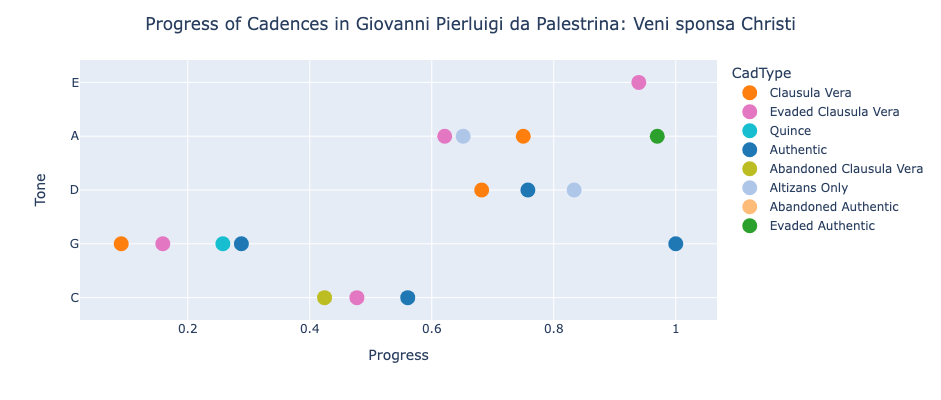

In [14]:

fig = px.scatter(
cadences,
x='Progress',
y='Tone',
color='CadType',
color_discrete_map=cadence_color_dict)

fig.update_traces(marker=dict(size=15))
   

fig.update_layout(
    title=f'Progress of Cadences in ' + piece.metadata['composer'] + ': ' + piece.metadata['title'],
height=400,
width=1000,
title_x=.5)

# Update y-axis configuration to use custom order
fig.update_yaxes(
    categoryorder='array',
    categoryarray=custom_tone_order
)


fig.show()

# 7 Corpus Methods

## 7a Build a Corpus

Here we obtain the MEI files from our work.


```python
# now specify YOUR pieces:
my_pieces = ['https://crimproject.org/mei/CRIM_Model_0019.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_1.mei', 'https://crimproject.org/mei/CRIM_Mass_0019_2.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_3.mei', 'https://crimproject.org/mei/CRIM_Mass_0019_4.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']
```
             
             


In [23]:

# now specify YOUR pieces:
my_pieces = ['https://crimproject.org/mei/CRIM_Model_0019.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_1.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_2.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_3.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_4.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']

# file_list = sorted(glob.glob('MEI/LC*'))
corpus = CorpusBase(my_pieces)


## 7b Interval Settings

The settings:  here we specify the various kinds of intervals and length of ngrams we want to find:

```python
combine_unisons_choice = False
combine_rests_choice = False
kind_choice = 'q'
directed_choice = False
compound_choice = False
exclude_rests = True
ngram_length = 4
```

These are in turn used with the various corpus functions we defined at the start of our notebook (see above).  For example:

`corpus_melodic = corpus_mel(corpus, kind_choice, compound_choice, directed_choice)`

or

`corpus_harmonic = corpus_har(corpus, kind_choice, compound_choice, directed_choice)`

or

`corpus_ngrams = corpus_ngrams(corpus, ngram_length, combine_rests_choice)`



In [24]:
# settings:  here we specify the various kinds of intervals and length of ngrams we want to find
combine_unisons_choice = False
combine_rests_choice = False
kind_choice = 'd'
directed_choice = False
compound_choice = False
exclude_rests = True
ngram_length = 4

## 7c. Corpus Notes as Barchart

Here we consider the *counts* of all the, voice by voice

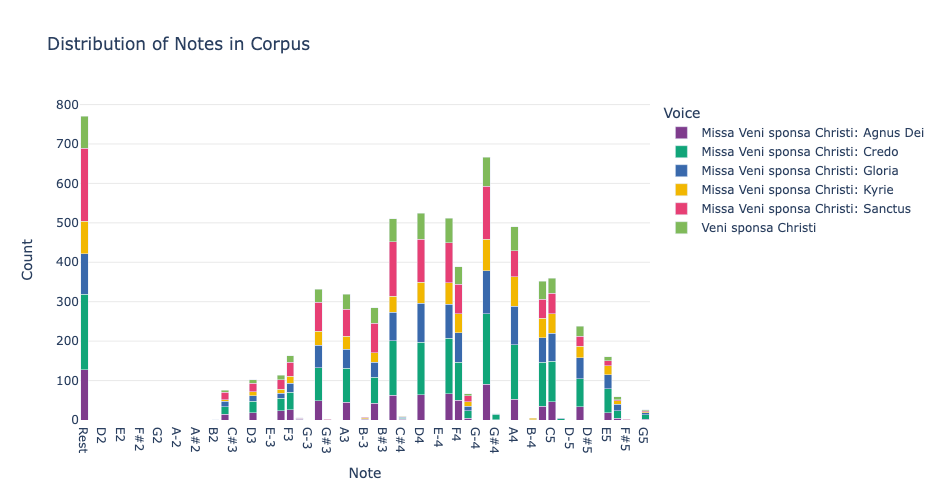

In [25]:

# run function and create chart
nr = corpus_notes(corpus, combine_unisons_choice, combine_rests_choice)

id_vars = ['Composer', 'Title', 'Date']

# Use list comprehension to determine value_vars
value_vars = [col for col in nr.columns if col not in id_vars]

# Melt the DataFrame
melted_df = pd.melt(
    nr,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Voice',
    value_name='Note'
)

melted_df['Note'] = melted_df['Note'].replace('NaN', np.nan)

# Remove NaN values for the visualization
melted_df_clean = melted_df.dropna(subset=['Note'])

# Create a basic bar chart showing the count of each note
chart_title = "Distribution of Notes in Corpus"

chosen_feature_to_compare = 'Title'

# Pre-aggregate the data (similar to your working example)
grouped_data = melted_df_clean.groupby(['Note', chosen_feature_to_compare]).size().reset_index(name='count')

# Create the bar chart with the pre-aggregated data
fig = px.bar(
    grouped_data,
    x='Note',
    y='count',
    color=chosen_feature_to_compare,
    barmode='stack',  # or 'group' if you prefer stacked bars
    color_discrete_sequence=px.colors.qualitative.Bold,  # Bold color scheme
    opacity=1.0,  # Full opacity for vibrant colors
    title=chart_title,
    category_orders={'Note': pitch_order}
)

# Update layout for clean appearance
fig.update_layout(
    xaxis_title="Note", 
    yaxis_title="Count",
    legend_title='Voice',
    height=500,
    width=900,
    plot_bgcolor='white',  # White background
    paper_bgcolor='white',  # White paper background
    xaxis={'categoryorder': 'array', 'categoryarray': pitch_order}
)

# Minimize grid lines
fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor='lightgray', gridwidth=0.5)

fig.show()

## 7d.  Corpus Ngrams Maps

Here we produce maps of the ngrams in each piece, in pairs:  model + mass movement.



In [26]:
# the ngram conditions
entries_only = True
combineUnisons = False
kind_choice ='d'
directed = True
compound = False
thematic = True
anywhere = True
n = 3
include_count = True


model = importScore(my_pieces[0])
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind_choice, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])
mod_mel_ngrams_duration = model.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

# find entries mass movements.  
# here we will display the results so that the motet is compared with each Kyrie, then each Gloria, etc
# in each case Lasso's Mass Movement will come first, then Daser's

mass_movements = my_pieces[1:]
for movement in mass_movements:       
    m_movement = importScore(movement)
    nr = m_movement.notes(combineUnisons=combineUnisons)
    mel = m_movement.melodic(df=nr, kind=kind_choice, compound=False, unit=0, end=False)
    mass_mvmt_mel_ngrams = m_movement.ngrams(df=mel, n=n)
    mass_mvmt_entries = m_movement.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere)
    mass_mvmt_mel_ngrams_duration = m_movement.durations(df=mel, n=n, mask_df=mass_mvmt_entries)
    mass_mvmt_entries_stack = mass_mvmt_entries.stack()
      
    # find shared entries
    shared_entries = list(set(mass_mvmt_entries_stack).intersection(mod_entries_stack))
    
    # print model metadata and chart
    print(model.metadata['composer'])
    print(model.metadata['title'])
    
    display(viz.plot_ngrams_heatmap(mod_entry_ngrams, 
                                    mod_mel_ngrams_duration, 
                        selected_patterns=shared_entries,
                        voices=[], 
                                    includeCount=False))
      
    # # print mass movement metadata and chart
    print(m_movement.metadata['composer'])
    print(m_movement.metadata['title'])
    display(viz.plot_ngrams_heatmap(mass_mvmt_entries, 
                                    mass_mvmt_mel_ngrams_duration, 
                                selected_patterns=shared_entries,
                                voices=[], 
                                    includeCount=False)) 
        

Giovanni Pierluigi da Palestrina
Veni sponsa Christi


alt.Chart(...)

Giovanni Pierluigi da Palestrina
Missa Veni sponsa Christi: Kyrie


alt.Chart(...)

Giovanni Pierluigi da Palestrina
Veni sponsa Christi


...

alt.Chart(...)

Giovanni Pierluigi da Palestrina
Veni sponsa Christi


alt.Chart(...)

Giovanni Pierluigi da Palestrina
Missa Veni sponsa Christi: Agnus Dei


alt.Chart(...)

## 7e.  Corpus Points of Imtiation and Specific Ngrams 

Here we show ways to filter Presentation Types to show only those with a given melodic idea.


In [28]:
# now specify YOUR pieces:
my_pieces = ['https://crimproject.org/mei/CRIM_Model_0019.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_1.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_2.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_3.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_4.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']
my_pieces


['https://crimproject.org/mei/CRIM_Model_0019.mei',
 'https://crimproject.org/mei/CRIM_Mass_0019_1.mei',
 'https://crimproject.org/mei/CRIM_Mass_0019_2.mei',
 'https://crimproject.org/mei/CRIM_Mass_0019_3.mei',
 'https://crimproject.org/mei/CRIM_Mass_0019_4.mei',
 'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']

In [29]:
melodic_ngram_length=3
end=False
kind='c'
combine_unisons=True 
include_hidden_types=False

my_tuple = ('-3', '3', '2')


for file in my_pieces:
    fileName = file.split("/")[4]
    piece = importScore(file)
    try:
        ptypes = piece.presentationTypes(melodic_ngram_length=melodic_ngram_length, 
                                         end=end, 
                                         kind=kind, 
                                         combine_unisons=combine_unisons, 
                                         include_hidden_types=include_hidden_types)
        if include_hidden_types == False:
            filter_condition = ptypes['Soggetti'].apply(lambda x: my_tuple in x)
            # Apply the filter to get the matching rows
            fitered_ptypes = ptypes[filter_condition]
            cols = ['Composer', 'Title', 'Presentation_Type', 'Soggetti', 'Voices', 
            'Number_Entries', 'Measures_Beats', 'Melodic_Entry_Intervals', 'Time_Entry_Intervals',	
            'Flexed_Entries', 'Parallel_Entries','Parallel_Voice', 'Count_Non_Overlaps', 'Offsets', 'Progress']     
            fitered_ptypes = fitered_ptypes[cols]
            piece.linkExamples(df = fitered_ptypes, piece_url=file)
        if include_hidden_types == True:
            filter_condition = ptypes['Soggetti'].apply(lambda x: my_tuple in x)
            # Apply the filter to get the matching rows
            fitered_ptypes = ptypes[filter_condition]
            cols = ['Composer', 'Title', 'Presentation_Type', 'Soggetti', 'Voices', 
            'Number_Entries', 'Measures_Beats', 'Melodic_Entry_Intervals', 'Time_Entry_Intervals',	
            'Flexed_Entries', 'Parallel_Entries','Parallel_Voice',  'Offsets', 'Progress']     
            fitered_ptypes = fitered_ptypes[cols]
            print(fileName)
            piece.linkExamples(df = fitered_ptypes, piece_url=url)
            
    except:
        print('No P Types found in ' + fileName)
        print('______')
        

,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Veni sponsa Christi,"<a href=""https://RichardFreedman.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fcrimproject.org%2Fmei%2FCRIM_Model_0019.mei&ema_expression=%2F1%2C11%2C12%2C13%2C14%2C15%2C16%2C17%2C18%2C19%2C2%2C3%2C4%2C6%2C7%2C8%2C9%2F1%2C2%2C2%2C2%2C1%2C1%2C1%2C4%2C4%2C4%2C1%2B2%2C1%2B2%2C2%2C3%2C3%2B4%2C3%2B4%2C4%2F%40all%2C%403.0-end%2C%40all%2C%401-3.0%2C%40all%2C%40all%2C%401-1.0%2C%40all%2C%40all%2C%401-1.0%2C%40all%2B%40all%2C%401-1.0%2B%40all%2C%401-1.0%2C%40all%2C%40all%2B%40all%2C%401-1.0%2B%40all%2C%401-1.0%2Fhighlight&measure_range=1-19&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA","[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus, Altus, Cantus, Bassus]",7,"[1.0/1.0, 2.0/1.0, 6.0/1.0, 7.0/1.0, 11.0/3.0, 14.0/1.0, 17.0/1.0]","[P-5, P-4, P-5, P8, P5, P-8]","[8.0, 32.0, 8.0, 36.0, 20.0, 24.0]",False,False,None,0,"[0.0, 8.0, 40.0, 48.0, 84.0, 104.0, 128.0]",0.0


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Kyrie,ID,"[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus]",4,"[1.0/1.0, 2.0/1.0, 6.0/1.0, 7.0/1.0]","[P-5, P-4, P-5]","[8.0, 32.0, 8.0]",False,False,None,0,"[0.0, 8.0, 40.0, 48.0]",0.0


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Gloria,FUGA,"[(-3, 3, 2)]","[Cantus, Tenor]",2,"[1.0/1.0, 4.0/3.0]",[P-8],[28.0],False,False,None,0,"[0.0, 28.0]",0.000000
5,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Gloria,FUGA,"[(-3, 3, 2)]","[Tenor, Cantus, Bassus, Altus, Bassus, Altus]",6,"[44.0/1.0, 45.0/1.0, 46.0/1.0, 47.0/1.0, 54.0/1.0, 55.0/2.0]","[P8, P-12, P8, P-8, P8]","[8.0, 8.0, 8.0, 56.0, 10.0]",False,False,None,1,"[352.0, 360.0, 368.0, 376.0, 432.0, 442.0]",0.444444


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Credo,FUGA,"[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus, Altus]",5,"[1.0/1.0, 2.0/1.0, 6.0/3.0, 7.0/1.0, 10.0/1.0]","[P-5, P-4, P-5, P8]","[8.0, 36.0, 4.0, 24.0]",False,False,None,0,"[0.0, 8.0, 44.0, 48.0, 72.0]",0.0


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Sanctus,FUGA,"[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus]",4,"[1.0/1.0, 3.0/1.0, 7.0/3.0, 12.0/1.0]","[P-5, P-4, P-5]","[16.0, 36.0, 36.0]",False,False,None,0,"[0.0, 16.0, 52.0, 88.0]",0.000000
8,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Sanctus,"<a href=""https://RichardFreedman.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fcrimproject.org%2Fmei%2FCRIM_Mass_0019_4.mei&ema_expression=%2F82%2C83%2C84%2C85%2C86%2C87%2C88%2C89%2C94%2C95%2C96%2C97%2C98%2C99%2F3%2C3%2B4%2C1%2B3%2B4%2C1%2B4%2C1%2C2%2C2%2C2%2C2%2C2%2C2%2C1%2C1%2C1%2F%40all%2C%40all%2B%40all%2C%40all%2B%401-1.0%2B%40all%2C%40all%2B%401-1.0%2C%401-1.0%2C%403.0-end%2C%40all%2C%401-3.0%2C%403.0-end%2C%40all%2C%401-3.0%2C%403.0-end%2C%40all%2C%401-3.0%2Fhighlight&measure_range=82-99&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA","[(-3, 3, 2)]","[Tenor, Bassus, Cantus, Altus, Altus, Cantus]",6,"[82.0/1.0, 83.0/1.0, 84.0/1.0, 87.0/3.0, 94.0/3.0, 97.0/3.0]","[P-5, P8, P1, P-4, P4]","[8.0, 8.0, 28.0, 56.0, 24.0]",False,False,None,1,"[760.0, 768.0, 776.0, 804.0, 860.0, 884.0]",0.730769


,Composer,Title,Presentation_Type,Soggetti,Voices,Number_Entries,Measures_Beats,Melodic_Entry_Intervals,Time_Entry_Intervals,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Offsets,Progress
0,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Agnus Dei,FUGA,"[(-3, 3, 2)]","[Cantus, Altus, Tenor, Bassus]",4,"[1.0/1.0, 2.0/1.0, 5.0/3.0, 7.0/3.0]","[P-5, P-4, P-5]","[8.0, 28.0, 16.0]",False,False,None,0,"[0.0, 8.0, 36.0, 52.0]",0.000000
4,Giovanni Pierluigi da Palestrina,Missa Veni sponsa Christi: Agnus Dei,FUGA,"[(-3, 3, 2)]","[Cantus, Altus, Quinta Pars]",3,"[35.0/1.0, 36.0/1.0, 38.0/1.0]","[P-5, P-4]","[8.0, 16.0]",False,False,None,0,"[280.0, 288.0, 304.0]",0.492958


## 7f.  Corpus Cadences with Examples


In [30]:

#  the corpus
my_pieces = ['https://crimproject.org/mei/CRIM_Model_0019.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_1.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_2.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_3.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_4.mei', 
             'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']


In [31]:
#build corpus
corpus = CorpusBase(my_pieces)

cadence_output = corpus_cadences(corpus)

In [32]:
cadence_output.to_csv('saved_csv/palestrina_cadences.csv')

## 7g  Distribution of Cadences by Tone and Type


    

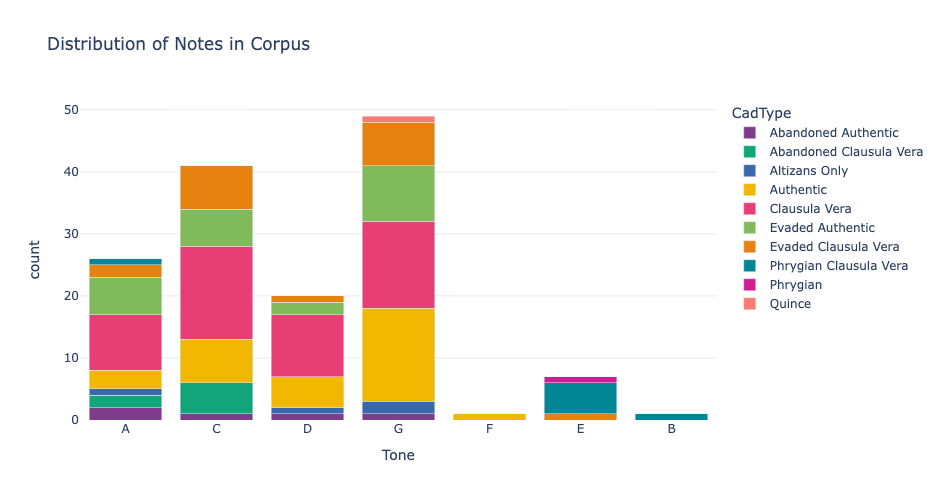

In [33]:
cadence_output = pd.read_csv('saved_csv/palestrina_cadences.csv')


# Create a basic bar chart showing the count of each note
chart_title = "Distribution of Notes in Corpus"

chosen_feature_to_compare = 'CadType'

# aggregate the data
grouped_data = cadence_output.groupby(['Tone', chosen_feature_to_compare]).size().reset_index(name='count')

# Create the bar chart with the pre-aggregated data
fig = px.bar(
    grouped_data,
    x='Tone',
    y='count',
    color=chosen_feature_to_compare,
    barmode='stack',  # or 'stack' if you prefer stacked bars
    color_discrete_sequence=px.colors.qualitative.Bold,  # Bold color scheme
    opacity=1.0,  # Full opacity for vibrant colors
    title=chart_title,
    category_orders={'Note': pitch_order}
)

# Update layout for clean appearance
fig.update_layout(
    xaxis_title="Tone", 
    yaxis_title="count",
    legend_title='CadType',
    height=500,
    width=900,
    plot_bgcolor='white',  # White background
    paper_bgcolor='white',  # White paper background
)

# Minimize grid lines
fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor='lightgray', gridwidth=0.5)

fig.show()



## 7h.  Radar Plot of Cadences in Corpus

Here we show the cadences in a polar plot, by proportion in each piece.

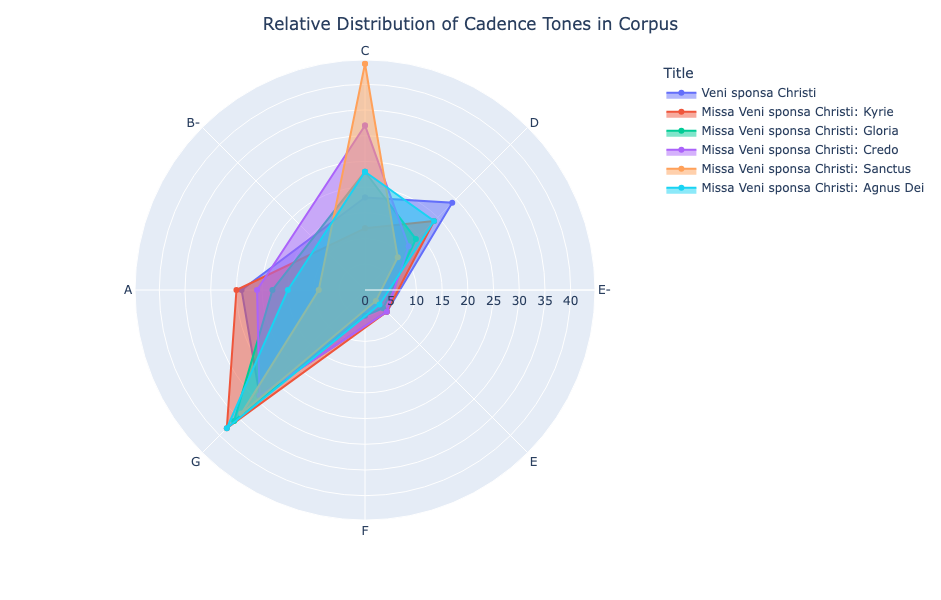

In [34]:

# Define the category order
category_order = {
    'C': 0, 'D': 1, 'E-': 2, 'E': 3, 'F': 4, 'G': 5, 'A': 6, 'B-': 7
}

# Get all unique titles for this final
titles = cadence_output['Title'].unique()

# Create a list to store our count data
count_data = []

# For each title, count the occurrences of each tone
for title in titles:
    title_data = cadence_output[cadence_output['Title'] == title]
    
    # Count occurrences of each Tone for this Title
    for tone in category_order.keys():
        count = len(title_data[title_data['Tone'] == tone])
        count_data.append({
            'Title': title,
            'Tone': tone,
            'count': count
        })

# Convert to DataFrame
count_df = pd.DataFrame(count_data)
count_df = count_df[count_df['count'] > 0]

# calculate % for each cadence vs total number of cadences for each piece
title_sums = count_df.groupby('Title')['count'].sum().reset_index()
title_sums.rename(columns={'count': 'TitleSum'}, inplace=True)

# Merge the sums back to the original DataFrame
count_df = count_df.merge(title_sums, on='Title', how='left')

# Calculate percentage
count_df['Percentage'] = np.round((count_df['count'] / count_df['TitleSum']) * 100)

# Create the radar plot with Plotly Express
fig = px.line_polar(
    count_df, 
    r='Percentage',       
    theta='Tone', 
    line_close=True,
    color='Title',
    markers=True,
    category_orders={'Tone': sorted(category_order.keys(), key=lambda x: category_order[x])}
)

# Update traces to fill the area
fig.update_traces(
    fill='toself',
    line=dict(width=2)
)

# Update layout with size control and legend positioning
fig.update_layout(
    # Control the size of the plot
    width=800,  # Width in pixels
    height=600,  # Height in pixels
 
    # Add title
    title_text="Relative Distribution of Cadence Tones in Corpus",
    title_x=0.5,  # Center the title
    
)

fig.show()